<a href="https://colab.research.google.com/github/AxelRM2709/Terminal_Economia_2026/blob/main/Expo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import datetime as dt
import plotly.express as px
import seaborn as sns
import geopy.distance
import matplotlib.pyplot as plt

df_GP = pd.read_csv("/content/Google-Playstore.csv")

In [ ]:
len(df_GP)

2312944

In [ ]:
df_GP.columns

Index(['App Name', 'App Id', 'Category', 'Rating', 'Rating Count', 'Installs',
       'Minimum Installs', 'Maximum Installs', 'Free', 'Price', 'Currency',
       'Size', 'Minimum Android', 'Developer Id', 'Developer Website',
       'Developer Email', 'Released', 'Last Updated', 'Content Rating',
       'Privacy Policy', 'Ad Supported', 'In App Purchases', 'Editors Choice',
       'Scraped Time'],
      dtype='object')

In [ ]:
df_GP.head()

,App Name,App Id,Category,Rating,Rating Count,Installs,Minimum Installs,Maximum Installs,Free,Price,...,Developer Website,Developer Email,Released,Last Updated,Content Rating,Privacy Policy,Ad Supported,In App Purchases,Editors Choice,Scraped Time
0,Gakondo,com.ishakwe.gakondo,Adventure,0.0,0.0,10+,10.0,15,True,0.0,...,https://beniyizibyose.tk/#/,jean21101999@gmail.com,"Feb 26, 2020","Feb 26, 2020",Everyone,https://beniyizibyose.tk/projects/,False,False,False,2021-06-15 20:19:35
1,Ampere Battery Info,com.webserveis.batteryinfo,Tools,4.4,64.0,"5,000+",5000.0,7662,True,0.0,...,https://webserveis.netlify.app/,webserveis@gmail.com,"May 21, 2020","May 06, 2021",Everyone,https://dev4phones.wordpress.com/licencia-de-uso/,True,False,False,2021-06-15 20:19:35
2,Vibook,com.doantiepvien.crm,Productivity,0.0,0.0,50+,50.0,58,True,0.0,...,NaN,vnacrewit@gmail.com,"Aug 9, 2019","Aug 19, 2019",Everyone,https://www.vietnamairlines.com/vn/en/terms-an...,False,False,False,2021-06-15 20:19:35
3,Smart City Trichy Public Service Vehicles 17UC...,cst.stJoseph.ug17ucs548,Communication,5.0,5.0,10+,10.0,19,True,0.0,...,http://www.climatesmarttech.com/,climatesmarttech2@gmail.com,"Sep 10, 2018","Oct 13, 2018",Everyone,NaN,True,False,False,2021-06-15 20:19:35
4,GROW.me,com.horodyski.grower,Tools,0.0,0.0,100+,100.0,478,True,0.0,...,http://www.horodyski.com.pl,rmilekhorodyski@gmail.com,"Feb 21, 2020","Nov 12, 2018",Everyone,http://www.horodyski.com.pl,False,False,False,2021-06-15 20:19:35


In [ ]:
columnas = list(df_GP.columns)
for i in range(0,len(columnas),6):
  input('\n\n------------------------------------------------------------------\n\n')
  print(df_GP[columnas[i:i+6]].head(3))



------------------------------------------------------------------


              App Name                      App Id      Category  Rating  \
0              Gakondo         com.ishakwe.gakondo     Adventure     0.0   
1  Ampere Battery Info  com.webserveis.batteryinfo         Tools     4.4   
2               Vibook        com.doantiepvien.crm  Productivity     0.0   

   Rating Count Installs  
0           0.0      10+  
1          64.0   5,000+  
2           0.0      50+  


------------------------------------------------------------------


   Minimum Installs  Maximum Installs  Free  Price Currency  Size
0              10.0                15  True    0.0      USD   10M
1            5000.0              7662  True    0.0      USD  2.9M
2              50.0                58  True    0.0      USD  3.7M


------------------------------------------------------------------


  Minimum Android                       Developer Id  \
0      7.1 and up  Jean Confident Irénée NIYIZIBYOSE  

# A considerar:

*   Revisar años de aplicaciones más exitosas
*   Categoria más exitosa
*   Tipo de Contenido más exitoso
*   Relación precio - descargas - calificación
*   Tamaño de nombres
*   Tamaño de aplicaciones
*   Ver si se siguen actualizando
*   Métodos de monetización
*   Aquellas con menor android mínimo tienen mejores resultados

# Limpieza y preparación de Datos

In [ ]:
df_GP.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2312944 entries, 0 to 2312943
Data columns (total 24 columns):
 #   Column             Dtype  
---  ------             -----  
 0   App Name           object 
 1   App Id             object 
 2   Category           object 
 3   Rating             float64
 4   Rating Count       float64
 5   Installs           object 
 6   Minimum Installs   float64
 7   Maximum Installs   int64  
 8   Free               bool   
 9   Price              float64
 10  Currency           object 
 11  Size               object 
 12  Minimum Android    object 
 13  Developer Id       object 
 14  Developer Website  object 
 15  Developer Email    object 
 16  Released           object 
 17  Last Updated       object 
 18  Content Rating     object 
 19  Privacy Policy     object 
 20  Ad Supported       bool   
 21  In App Purchases   bool   
 22  Editors Choice     bool   
 23  Scraped Time       object 
dtypes: bool(4), float64(4), int64(1), object(15)
memor

In [ ]:
df_GP.nunique()

,0
App Name,2177943
App Id,2312944
Category,48
Rating,42
Rating Count,38482
Installs,22
Minimum Installs,22
Maximum Installs,251563
Free,2
Price,1063


In [ ]:
df_GP.isna().sum()

,0
App Name,5
App Id,0
Category,0
Rating,22883
Rating Count,22883
Installs,107
Minimum Installs,107
Maximum Installs,0
Free,0
Price,0


In [ ]:
df_GP['Scraped Time'].max()

'2021-06-16 15:10:42'

In [ ]:
df_GP['Scraped Time'].min()

'2021-06-15 20:19:35'

Eliminamos columnas que no parecen ser interesantes para nuestro proposito como información de los desarrolladores (excepto su id) o las póliticas de privacidad. Dado que la información se extrajo en un lapso de 2 días, tampoco es relevante la columna 'Scraped Time' y no sé que sea editors choice, por lo que tampoco se considerará

In [ ]:
df_GP = df_GP.drop(columns=['Developer Website', 'Developer Email', 'Privacy Policy',
              'Editors Choice', 'Scraped Time'])

In [ ]:
df_Pruebas = df_GP[['Minimum Android']].copy()

In [ ]:
df_Pruebas

,Minimum Android
0,7.1 and up
1,5.0 and up
2,4.0.3 and up
3,4.0.3 and up
4,4.1 and up
...,...
2312939,4.1 and up
2312940,4.1 and up
2312941,5.0 and up
2312942,5.0 and up


In [ ]:
df_Pruebas['M_A'] = df_Pruebas['Minimum Android'].astype(str).str.split()

In [ ]:
df_Pruebas['2nd'] = df_Pruebas['M_A'].apply(lambda x: x[1] if isinstance(x, list) and len(x) > 1 else None)

In [ ]:
df_Pruebas['2nd'].unique()

array(['and', None, 'with', '-'], dtype=object)

In [ ]:
df_Pruebas = df_Pruebas.dropna(subset=['Minimum Android', '2nd'])
print(len(df_Pruebas[df_Pruebas['2nd'] != 'and']))
df_Pruebas['Minimum Android'][df_Pruebas['2nd'] != 'and'].unique()

46667


array(['Varies with device', '4.0.3 - 7.1.1', '4.4 - 6.0', '2.1 - 4.4',
       '4.0 - 5.0', '2.0 - 2.3.4', '2.2 - 4.4', '4.1 - 7.0', '4.1 - 6.0',
       '4.0 - 4.4W', '4.0 - 4.4', '4.0.3 - 7.0', '2.3 - 5.0',
       '4.0 - 7.1.1', '4.1 - 7.1.1', '4.0 - 7.0', '4.1 - 8.0',
       '4.0 - 6.0', '2.3 - 7.0', '4.0 - 8.0', '2.3 - 6.0', '2.1 - 2.3.4',
       '3.0 - 4.1.1', '2.2 - 3.0', '2.0 - 8.0', '4.0.3 - 8.0',
       '3.0 - 4.4W', '4.4 - 7.1.1', '4.4 - 8.0', '4.0.3 - 6.0',
       '1.6 - 4.0.4', '2.3 - 5.1', '2.1 - 7.1.1', '2.3 - 4.4W',
       '4.4 - 7.0', '6.0 - 7.1.1', '2.3 - 4.4', '2.2 - 4.0.4',
       '2.1 - 4.1.1', '3.0 - 8.0', '3.0 - 5.1', '2.1 - 6.0', '6.0 - 8.0',
       '5.0 - 8.0', '4.1 - 5.1', '3.2 - 4.4', '2.1 - 5.0', '4.1 - 4.3',
       '5.0 - 6.0', '5.1 - 7.1.1', '2.2 - 5.1', '4.1 - 5.0',
       '2.3.3 - 4.4', '2.2 - 5.0', '4.1 - 4.4', '1.6 - 5.1',
       '4.2 - 7.1.1', '2.1 - 5.1', '1.6 - 4.4W', '4.3 - 4.4W',
       '3.0 - 4.4', '2.1 - 3.1', '2.3 - 7.1.1', '1.6 - 4.0.2',
       

Consideraré solo las primeras versiones y el posteriores estará implícito, pues los que no lo tienen son una cantidad pequeña a comparación del tamaño total de la base de datos

In [ ]:
df_GP.isna().sum()

,0
App Name,5
App Id,0
Category,0
Rating,22883
Rating Count,22883
Installs,107
Minimum Installs,107
Maximum Installs,0
Free,0
Price,0


In [ ]:
df_GP = df_GP.dropna(subset=['Minimum Android', 'Released', 'Rating', 'Rating Count', 'App Name', 'Developer Id', 'Currency'])
df_GP['Android'] = df_GP['Minimum Android'].str[:3] # 4.5, por ejemplo
df_GP = df_GP[df_GP['Android'].str[0].str.isdigit()]

In [ ]:
df_GP.head()

,App Name,App Id,Category,Rating,Rating Count,Installs,Minimum Installs,Maximum Installs,Free,Price,Currency,Size,Minimum Android,Developer Id,Released,Last Updated,Content Rating,Ad Supported,In App Purchases,Android
0,Gakondo,com.ishakwe.gakondo,Adventure,0.0,0.0,10+,10.0,15,True,0.0,USD,10M,7.1 and up,Jean Confident Irénée NIYIZIBYOSE,"Feb 26, 2020","Feb 26, 2020",Everyone,False,False,7.1
1,Ampere Battery Info,com.webserveis.batteryinfo,Tools,4.4,64.0,"5,000+",5000.0,7662,True,0.0,USD,2.9M,5.0 and up,Webserveis,"May 21, 2020","May 06, 2021",Everyone,True,False,5.0
2,Vibook,com.doantiepvien.crm,Productivity,0.0,0.0,50+,50.0,58,True,0.0,USD,3.7M,4.0.3 and up,Cabin Crew,"Aug 9, 2019","Aug 19, 2019",Everyone,False,False,4.0
3,Smart City Trichy Public Service Vehicles 17UC...,cst.stJoseph.ug17ucs548,Communication,5.0,5.0,10+,10.0,19,True,0.0,USD,1.8M,4.0.3 and up,Climate Smart Tech2,"Sep 10, 2018","Oct 13, 2018",Everyone,True,False,4.0
4,GROW.me,com.horodyski.grower,Tools,0.0,0.0,100+,100.0,478,True,0.0,USD,6.2M,4.1 and up,Rafal Milek-Horodyski,"Feb 21, 2020","Nov 12, 2018",Everyone,False,False,4.1


In [ ]:
df_GP['Released_M'] = df_GP['Released'].str[:3]

In [ ]:
df_GP['Released_M'].unique() # Comprobamos que solo estén los meses

array(['Feb', 'May', 'Aug', 'Sep', 'Dec', 'Jun', 'Jul', 'Jan', 'Apr',
       'Nov', 'Mar', 'Oct'], dtype=object)

In [ ]:
df_GP['Released_Y'] = df_GP['Released'].str[-4:]

In [ ]:
df_GP['Released_Y'].unique()

array(['2020', '2019', '2018', '2016', '2021', '2017', '2015', '2013',
       '2012', '2014', '2011', '2010'], dtype=object)

In [ ]:
Meses = {
    'Jan':1,
    'Feb':2,
    'Mar':3,
    'Apr':4,
    'May':5,
    'Jun':6,
    'Jul':7,
    'Aug':8,
    'Sep':9,
    'Oct':10,
    'Nov':11,
    'Dec':12
}

In [ ]:
df_GP['Released_Month'] = df_GP['Released_M'].map(Meses)
df_GP['Released_Year'] = df_GP['Released_Y'].astype(int)

In [ ]:
df_GP.head(10)

,App Name,App Id,Category,Rating,Rating Count,Installs,Minimum Installs,Maximum Installs,Free,Price,...,Released,Last Updated,Content Rating,Ad Supported,In App Purchases,Android,Released_M,Released_Y,Released_Month,Released_Year
0,Gakondo,com.ishakwe.gakondo,Adventure,0.0,0.0,10+,10.0,15,True,0.0,...,"Feb 26, 2020","Feb 26, 2020",Everyone,False,False,7.1,Feb,2020,2,2020
1,Ampere Battery Info,com.webserveis.batteryinfo,Tools,4.4,64.0,"5,000+",5000.0,7662,True,0.0,...,"May 21, 2020","May 06, 2021",Everyone,True,False,5.0,May,2020,5,2020
2,Vibook,com.doantiepvien.crm,Productivity,0.0,0.0,50+,50.0,58,True,0.0,...,"Aug 9, 2019","Aug 19, 2019",Everyone,False,False,4.0,Aug,2019,8,2019
3,Smart City Trichy Public Service Vehicles 17UC...,cst.stJoseph.ug17ucs548,Communication,5.0,5.0,10+,10.0,19,True,0.0,...,"Sep 10, 2018","Oct 13, 2018",Everyone,True,False,4.0,Sep,2018,9,2018
4,GROW.me,com.horodyski.grower,Tools,0.0,0.0,100+,100.0,478,True,0.0,...,"Feb 21, 2020","Nov 12, 2018",Everyone,False,False,4.1,Feb,2020,2,2020
5,IMOCCI,com.imocci,Social,0.0,0.0,50+,50.0,89,True,0.0,...,"Dec 24, 2018","Dec 20, 2019",Teen,False,True,6.0,Dec,2018,12,2018
6,unlimited 4G data prank free app,getfreedata.superfatiza.unlimitedjiodataprank,Libraries & Demo,4.5,12.0,"1,000+",1000.0,2567,True,0.0,...,"Sep 23, 2019","Sep 27, 2019",Everyone,True,False,4.1,Sep,2019,9,2019
7,The Everyday Calendar,com.mozaix.simoneboard,Lifestyle,2.0,39.0,500+,500.0,702,True,0.0,...,"Jun 21, 2019","Jun 21, 2019",Everyone,False,False,5.0,Jun,2019,6,2019
9,Neon 3d Iron Tech Keyboard Theme,com.ikeyboard.theme.neon_3d.iron.tech,Personalization,4.7,820.0,"50,000+",50000.0,62433,True,0.0,...,"Sep 22, 2019","Oct 07, 2020",Everyone,True,False,4.1,Sep,2019,9,2019
10,Dodge The Cars!,com.MrScratchEnterprises.CarDogeGame,Racing,4.9,55.0,100+,100.0,329,True,0.0,...,"Jul 30, 2020","Jul 30, 2020",Everyone,False,False,4.4,Jul,2020,7,2020


In [ ]:
df_GP['L_Updated_M'] = df_GP['Last Updated'].str[:3]
df_GP['L_Updated_Y'] = df_GP['Last Updated'].str[-4:]
df_GP['L_Updated_Month'] = df_GP['L_Updated_M'].map(Meses)
df_GP['L_Updated_Year'] = df_GP['L_Updated_Y'].astype(int)
df_GP = df_GP.drop(columns = ['L_Updated_M','L_Updated_Y','Last Updated', 'Released', 'Released_M','Released_Y', 'Minimum Android'])
df_GP.head()

,App Name,App Id,Category,Rating,Rating Count,Installs,Minimum Installs,Maximum Installs,Free,Price,...,Size,Developer Id,Content Rating,Ad Supported,In App Purchases,Android,Released_Month,Released_Year,L_Updated_Month,L_Updated_Year
0,Gakondo,com.ishakwe.gakondo,Adventure,0.0,0.0,10+,10.0,15,True,0.0,...,10M,Jean Confident Irénée NIYIZIBYOSE,Everyone,False,False,7.1,2,2020,2,2020
1,Ampere Battery Info,com.webserveis.batteryinfo,Tools,4.4,64.0,"5,000+",5000.0,7662,True,0.0,...,2.9M,Webserveis,Everyone,True,False,5.0,5,2020,5,2021
2,Vibook,com.doantiepvien.crm,Productivity,0.0,0.0,50+,50.0,58,True,0.0,...,3.7M,Cabin Crew,Everyone,False,False,4.0,8,2019,8,2019
3,Smart City Trichy Public Service Vehicles 17UC...,cst.stJoseph.ug17ucs548,Communication,5.0,5.0,10+,10.0,19,True,0.0,...,1.8M,Climate Smart Tech2,Everyone,True,False,4.0,9,2018,10,2018
4,GROW.me,com.horodyski.grower,Tools,0.0,0.0,100+,100.0,478,True,0.0,...,6.2M,Rafal Milek-Horodyski,Everyone,False,False,4.1,2,2020,11,2018


In [ ]:
df_GP = df_GP.reset_index()

In [ ]:
df_GP

,index,App Name,App Id,Category,Rating,Rating Count,Installs,Minimum Installs,Maximum Installs,Free,...,Size,Developer Id,Content Rating,Ad Supported,In App Purchases,Android,Released_Month,Released_Year,L_Updated_Month,L_Updated_Year
0,0,Gakondo,com.ishakwe.gakondo,Adventure,0.0,0.0,10+,10.0,15,True,...,10M,Jean Confident Irénée NIYIZIBYOSE,Everyone,False,False,7.1,2,2020,2,2020
1,1,Ampere Battery Info,com.webserveis.batteryinfo,Tools,4.4,64.0,"5,000+",5000.0,7662,True,...,2.9M,Webserveis,Everyone,True,False,5.0,5,2020,5,2021
2,2,Vibook,com.doantiepvien.crm,Productivity,0.0,0.0,50+,50.0,58,True,...,3.7M,Cabin Crew,Everyone,False,False,4.0,8,2019,8,2019
3,3,Smart City Trichy Public Service Vehicles 17UC...,cst.stJoseph.ug17ucs548,Communication,5.0,5.0,10+,10.0,19,True,...,1.8M,Climate Smart Tech2,Everyone,True,False,4.0,9,2018,10,2018
4,4,GROW.me,com.horodyski.grower,Tools,0.0,0.0,100+,100.0,478,True,...,6.2M,Rafal Milek-Horodyski,Everyone,False,False,4.1,2,2020,11,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2211968,2312938,Lero TOEFL Recorder + Timer,com.toefltimer,Education,3.4,17.0,"1,000+",1000.0,1980,True,...,10M,Julio Augusto Vera,Everyone,True,False,4.1,5,2018,12,2018
2211969,2312940,ORU Online,com.threedream.oruonline,Education,0.0,0.0,100+,100.0,430,True,...,44M,"3Dream Studios, LLC",Everyone,False,False,4.1,1,2018,2,2018
2211970,2312941,Data Structure,datastructure.appoworld.datastucture,Education,0.0,0.0,100+,100.0,202,True,...,29M,appoworld,Everyone,False,False,5.0,8,2018,8,2018
2211971,2312942,Devi Suktam,ishan.devi.suktam,Music & Audio,3.5,8.0,"1,000+",1000.0,2635,True,...,10M,Bhakti,Everyone,True,False,5.0,8,2016,5,2021


# Análisis exploratorio

In [ ]:
print(f"Media de Ratings: {df_GP['Rating'].mean()}")

Media de Ratings: 2.1951336205279195


In [ ]:
df_GP['Installs'].unique()

array(['10+', '5,000+', '50+', '100+', '1,000+', '500+', '50,000+',
       '10,000+', '1+', '500,000+', '100,000+', '5+', '10,000,000+',
       '1,000,000+', '5,000,000+', '0+', '100,000,000+', '50,000,000+',
       '1,000,000,000+', '500,000,000+'], dtype=object)

In [ ]:
df_GP['No. Installs'] = df_GP['Installs'].str.replace(r'[+,]', '', regex=True).astype(int)

In [ ]:
# Normalización de los datos
df_GP['Installs_Log'] = np.log1p(df_GP['No. Installs'])
media_log = df_GP['Installs_Log'].mean()
std_log = df_GP['Installs_Log'].std()

df_GP['z_score_log'] = (df_GP['Installs_Log'] - media_log) / std_log

In [ ]:
df_GP['Installs_Log'].skew()

np.float64(0.44672239588979945)

In [ ]:
df_GP.head()

,index,App Name,App Id,Category,Rating,Rating Count,Installs,Minimum Installs,Maximum Installs,Free,...,Ad Supported,In App Purchases,Android,Released_Month,Released_Year,L_Updated_Month,L_Updated_Year,No. Installs,Installs_Log,z_score_log
0,0,Gakondo,com.ishakwe.gakondo,Adventure,0.0,0.0,10+,10.0,15,True,...,False,False,7.1,2,2020,2,2020,10,2.397895,-1.203125
1,1,Ampere Battery Info,com.webserveis.batteryinfo,Tools,4.4,64.0,"5,000+",5000.0,7662,True,...,True,False,5.0,5,2020,5,2021,5000,8.517393,0.758150
2,2,Vibook,com.doantiepvien.crm,Productivity,0.0,0.0,50+,50.0,58,True,...,False,False,4.0,8,2019,8,2019,50,3.931826,-0.711506
3,3,Smart City Trichy Public Service Vehicles 17UC...,cst.stJoseph.ug17ucs548,Communication,5.0,5.0,10+,10.0,19,True,...,True,False,4.0,9,2018,10,2018,10,2.397895,-1.203125
4,4,GROW.me,com.horodyski.grower,Tools,0.0,0.0,100+,100.0,478,True,...,False,False,4.1,2,2020,11,2018,100,4.615121,-0.492513


In [ ]:
df_GP['No. Installs'].value_counts()

,count
No. Installs,
100,426827
1000,382949
10,286727
10000,245317
500,181714
50,163975
5000,137696
100000,103864
50000,71548


In [ ]:
def asignar_nota(n):
    if n >= 50000000:   return "Excelente (Viral)"
    if n >= 1000000:    return "Bueno (Consolidada)"
    if n >= 100000:     return "Regular (En Crecimiento)"
    if n >= 1000:       return "Malo (Nicho)"
    else:               return "Muy malo (Emergente)"

In [ ]:
df_GP['Score'] = df_GP['No. Installs'].apply(asignar_nota)

In [ ]:
df_GP['Score'].value_counts()

,count
Score,
Muy malo (Emergente),1201797
Malo (Nicho),837510
Regular (En Crecimiento),129097
Bueno (Consolidada),42426
Excelente (Viral),1143


In [ ]:
sum = df_GP['Score'].value_counts().sum()
for i in df_GP['Score'].value_counts():
  print(f"{round(i/sum,2)}%")

0.45%
0.24%
0.21%
0.08%
0.03%


In [ ]:
cortes_z = {
    "Excelente": 1.5,
    "Bueno": 0.5,
    "Regular": -0.5,
    "Malo": -1.5
}
for etiqueta, z in cortes_z.items():
    valor_real = media_log + (z * std_log)
    print(f"{etiqueta}: {valor_real:,.2f} instalaciones")

Excelente: 10.83 instalaciones
Bueno: 7.71 instalaciones
Regular: 4.59 instalaciones
Malo: 1.47 instalaciones


In [ ]:
df_GP['No. Installs'][df_GP['Score']=='Regular'].min()

nan

In [ ]:
df_GP

,index,App Name,App Id,Category,Rating,Rating Count,Installs,Minimum Installs,Maximum Installs,Free,...,In App Purchases,Android,Released_Month,Released_Year,L_Updated_Month,L_Updated_Year,No. Installs,Installs_Log,z_score_log,Score
0,0,Gakondo,com.ishakwe.gakondo,Adventure,0.0,0.0,10+,10.0,15,True,...,False,7.1,2,2020,2,2020,10,2.397895,-1.203125,Muy malo (Emergente)
1,1,Ampere Battery Info,com.webserveis.batteryinfo,Tools,4.4,64.0,"5,000+",5000.0,7662,True,...,False,5.0,5,2020,5,2021,5000,8.517393,0.758150,Malo (Nicho)
2,2,Vibook,com.doantiepvien.crm,Productivity,0.0,0.0,50+,50.0,58,True,...,False,4.0,8,2019,8,2019,50,3.931826,-0.711506,Muy malo (Emergente)
3,3,Smart City Trichy Public Service Vehicles 17UC...,cst.stJoseph.ug17ucs548,Communication,5.0,5.0,10+,10.0,19,True,...,False,4.0,9,2018,10,2018,10,2.397895,-1.203125,Muy malo (Emergente)
4,4,GROW.me,com.horodyski.grower,Tools,0.0,0.0,100+,100.0,478,True,...,False,4.1,2,2020,11,2018,100,4.615121,-0.492513,Muy malo (Emergente)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2211968,2312938,Lero TOEFL Recorder + Timer,com.toefltimer,Education,3.4,17.0,"1,000+",1000.0,1980,True,...,False,4.1,5,2018,12,2018,1000,6.908755,0.242588,Malo (Nicho)
2211969,2312940,ORU Online,com.threedream.oruonline,Education,0.0,0.0,100+,100.0,430,True,...,False,4.1,1,2018,2,2018,100,4.615121,-0.492513,Muy malo (Emergente)
2211970,2312941,Data Structure,datastructure.appoworld.datastucture,Education,0.0,0.0,100+,100.0,202,True,...,False,5.0,8,2018,8,2018,100,4.615121,-0.492513,Muy malo (Emergente)
2211971,2312942,Devi Suktam,ishan.devi.suktam,Music & Audio,3.5,8.0,"1,000+",1000.0,2635,True,...,False,5.0,8,2016,5,2021,1000,6.908755,0.242588,Malo (Nicho)


In [ ]:
df_GP.columns

Index(['index', 'App Name', 'App Id', 'Category', 'Rating', 'Rating Count',
       'Installs', 'Minimum Installs', 'Maximum Installs', 'Free', 'Price',
       'Currency', 'Size', 'Developer Id', 'Content Rating', 'Ad Supported',
       'In App Purchases', 'Android', 'Released_Month', 'Released_Year',
       'L_Updated_Month', 'L_Updated_Year', 'No. Installs', 'Installs_Log',
       'z_score_log', 'Score'],
      dtype='object')

In [ ]:
# Nuevos dataframes para facilitar lectura y organizar información
df_Cal = df_GP[['App Id','Rating','Rating Count','No. Installs','Score']].copy()    # Calificaciones
df_Info = df_GP[['App Id','App Name','Category','Currency','Size','Android','Developer Id',
                 'Released_Month', 'Released_Year','L_Updated_Month',
                 'L_Updated_Year']].copy()                                          # Información de la app
df_Mon = df_GP[['App Id','Free','Price','Ad Supported','In App Purchases']].copy()  # Monetización

In [ ]:
df_Cal

,App Id,Rating,Rating Count,No. Installs,Score
0,com.ishakwe.gakondo,0.0,0.0,10,Muy malo (Emergente)
1,com.webserveis.batteryinfo,4.4,64.0,5000,Malo (Nicho)
2,com.doantiepvien.crm,0.0,0.0,50,Muy malo (Emergente)
3,cst.stJoseph.ug17ucs548,5.0,5.0,10,Muy malo (Emergente)
4,com.horodyski.grower,0.0,0.0,100,Muy malo (Emergente)
...,...,...,...,...,...
2211968,com.toefltimer,3.4,17.0,1000,Malo (Nicho)
2211969,com.threedream.oruonline,0.0,0.0,100,Muy malo (Emergente)
2211970,datastructure.appoworld.datastucture,0.0,0.0,100,Muy malo (Emergente)
2211971,ishan.devi.suktam,3.5,8.0,1000,Malo (Nicho)


In [ ]:
df_Cal = df_Cal.sort_values(by = 'No. Installs')

In [ ]:
df_Cal['Score'].value_counts()

,count
Score,
Muy malo (Emergente),1201797
Malo (Nicho),837510
Regular (En Crecimiento),129097
Bueno (Consolidada),42426
Excelente (Viral),1143


In [ ]:
df_Info

,App Id,App Name,Category,Currency,Size,Android,Developer Id,Released_Month,Released_Year,L_Updated_Month,L_Updated_Year
0,com.ishakwe.gakondo,Gakondo,Adventure,USD,10M,7.1,Jean Confident Irénée NIYIZIBYOSE,2,2020,2,2020
1,com.webserveis.batteryinfo,Ampere Battery Info,Tools,USD,2.9M,5.0,Webserveis,5,2020,5,2021
2,com.doantiepvien.crm,Vibook,Productivity,USD,3.7M,4.0,Cabin Crew,8,2019,8,2019
3,cst.stJoseph.ug17ucs548,Smart City Trichy Public Service Vehicles 17UC...,Communication,USD,1.8M,4.0,Climate Smart Tech2,9,2018,10,2018
4,com.horodyski.grower,GROW.me,Tools,USD,6.2M,4.1,Rafal Milek-Horodyski,2,2020,11,2018
...,...,...,...,...,...,...,...,...,...,...,...
2211968,com.toefltimer,Lero TOEFL Recorder + Timer,Education,USD,10M,4.1,Julio Augusto Vera,5,2018,12,2018
2211969,com.threedream.oruonline,ORU Online,Education,USD,44M,4.1,"3Dream Studios, LLC",1,2018,2,2018
2211970,datastructure.appoworld.datastucture,Data Structure,Education,USD,29M,5.0,appoworld,8,2018,8,2018
2211971,ishan.devi.suktam,Devi Suktam,Music & Audio,USD,10M,5.0,Bhakti,8,2016,5,2021


# Cuántas aplicaciones se lanzaron por año

In [ ]:
# Colores
colores = ['#B0001B', '#F57A25', '#FFC20A', '#24BD51', '#3F48CC']
paleta = sns.color_palette(colores)

/tmp/ipykernel_5947/1443818508.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_Info, x='Released_Year', palette='viridis')


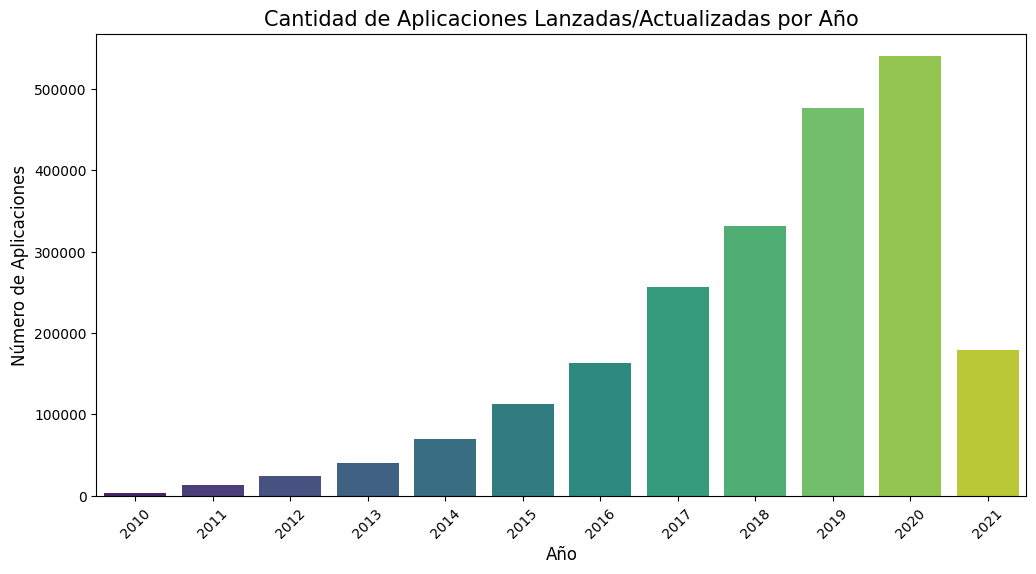

In [ ]:
plt.figure(figsize=(12, 6))

ax = sns.countplot(data=df_Info, x='Released_Year', palette='viridis')

plt.title('Cantidad de Aplicaciones Lanzadas/Actualizadas por Año', fontsize=15)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Número de Aplicaciones', fontsize=12)
plt.xticks(rotation=45) # Rota los años para que no se amontonen

plt.show()

# Cuántas Aplicaciones se lanzaron por mes

/tmp/ipykernel_5947/3217458923.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_Info, x='Released_Month', palette='viridis')


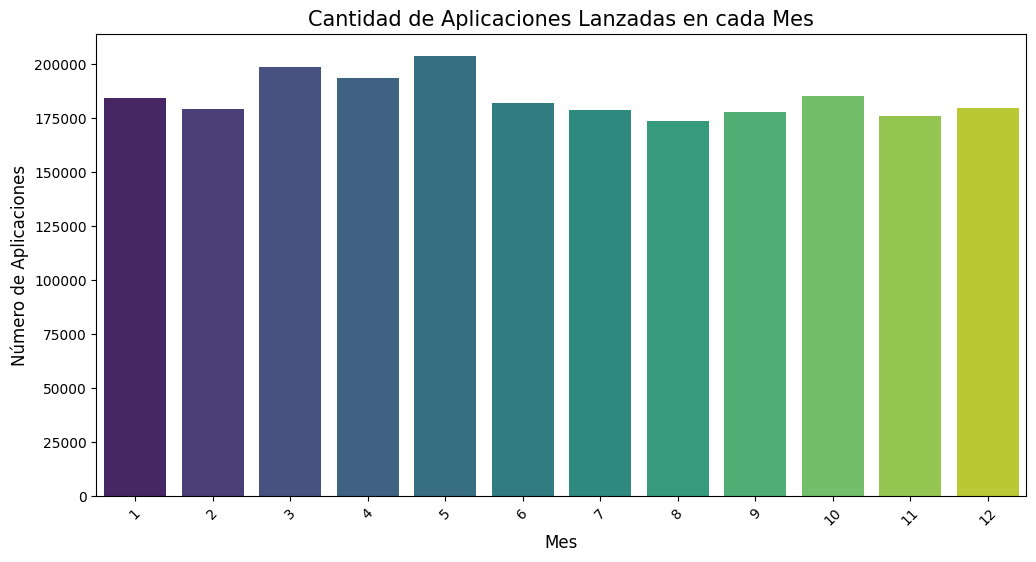

In [ ]:
plt.figure(figsize=(12, 6))

ax = sns.countplot(data=df_Info, x='Released_Month', palette='viridis')

plt.title('Cantidad de Aplicaciones Lanzadas en cada Mes', fontsize=15)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Número de Aplicaciones', fontsize=12)
plt.xticks(rotation=45)

plt.show()

In [ ]:
import gc
#del df_viejo
#gc.collect()

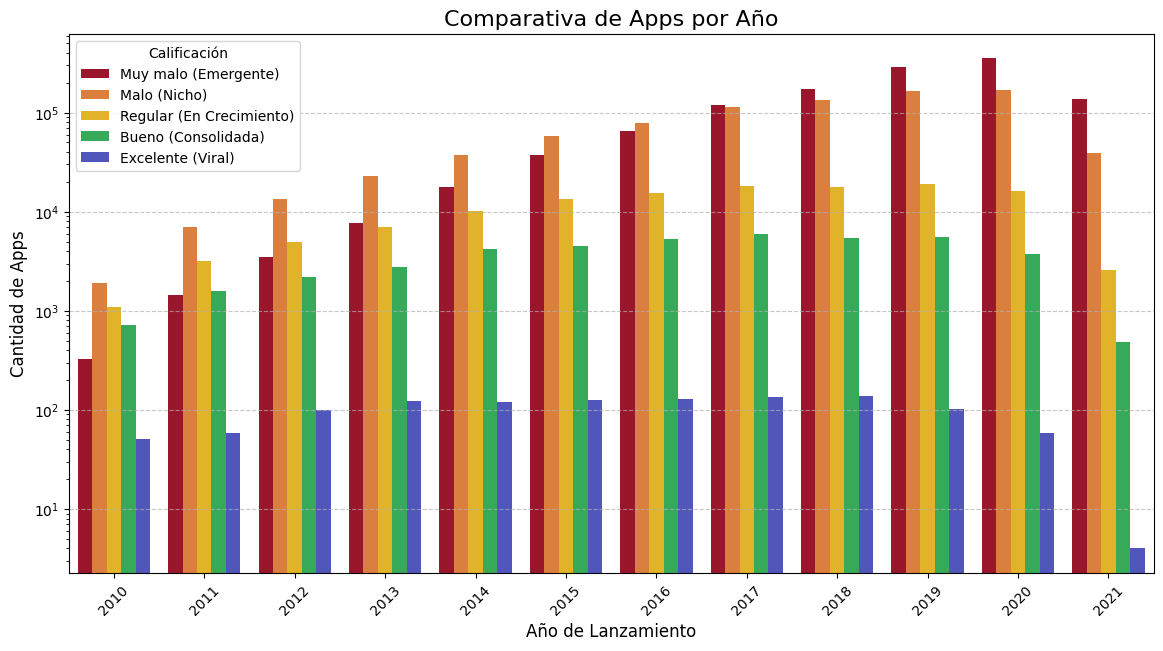

18447

In [ ]:
df_ComparacionScore = pd.merge(df_Cal[['App Id','Score']], df_Info[['App Id','Released_Year']], on = 'App Id')
plt.figure(figsize=(14, 7))

ax = sns.countplot(data=df_ComparacionScore, x='Released_Year', hue='Score', palette = paleta)

ax.set_yscale("log")
# Configuración estética
plt.title('Comparativa de Apps por Año', fontsize=16)
plt.xlabel('Año de Lanzamiento', fontsize=12)
plt.ylabel('Cantidad de Apps', fontsize=12)
plt.legend(title='Calificación')
plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

del df_ComparacionScore
gc.collect()

In [ ]:
del df_GP
gc.collect()

0

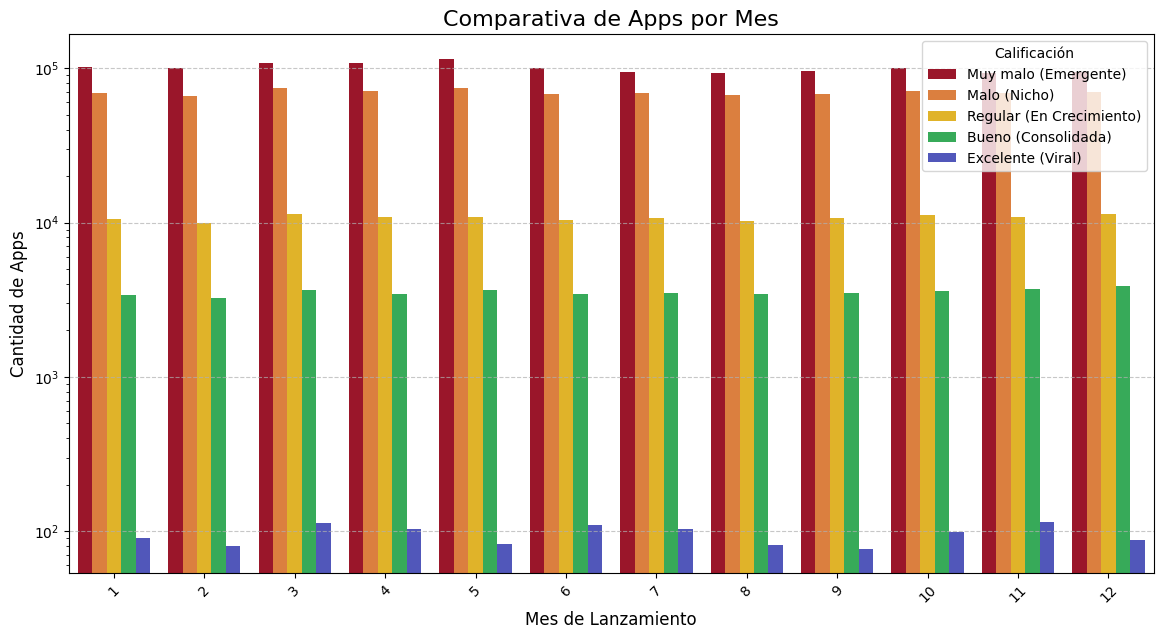

17876

In [ ]:
df_ComparacionScore = pd.merge(df_Cal[['App Id','Score']], df_Info[['App Id','Released_Month']], on = 'App Id')
plt.figure(figsize=(14, 7))

ax = sns.countplot(data=df_ComparacionScore, x='Released_Month', hue='Score', palette=paleta)
ax.set_yscale("log")
# Configuración estética
plt.title('Comparativa de Apps por Mes', fontsize=16)
plt.xlabel('Mes de Lanzamiento', fontsize=12)
plt.ylabel('Cantidad de Apps', fontsize=12)
plt.legend(title='Calificación')
plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

del df_ComparacionScore
gc.collect()

## Concluciones
Parece ser que no hay un mes donde las empresas prefieran lanzar sus aplicaciones, aunque mayo supera ligeramente el promedio, lo que indica que no hay un mes favorable o desfavorable para lanzar una aplicación. La cantidad de aplicaciones lanzadas aumenta enormemente cada año, si bien los datos solo llegan hasta mediados del 2021 y este parece ser una excepción a la regla, es probable que esto se deba a la pandemia. Esto último sugiere que año con año la competencia es mayor.

# Tamaño de Nombre de Aplicaciones

In [ ]:
df_ComparacionScore = pd.merge(df_Cal[['App Id','Score']], df_Info[['App Id','App Name']], on = 'App Id')
df_ComparacionScore['Len Name'] = df_ComparacionScore['App Name'].apply(len)

In [ ]:
def clasificacionLenName(n):
  r = 9 # Parece que con 9 había una menor diferencia entre los valores
  if n<=r:
    return 'Muy Corto (-9)'
  elif r<n<=2*r:
    return 'Corto (10 - 18)'
  elif 2*r<n<=3*r:
    return 'Grande (19 - 27)'
  else:
    return 'Muy Grande (27+)'
df_ComparacionScore['Len Class'] = df_ComparacionScore['Len Name'].apply(clasificacionLenName)

In [ ]:
df_ComparacionScore['Len Class'].value_counts()

,count
Len Class,
Corto (10 - 18),747353
Muy Grande (27+),626235
Grande (19 - 27),556882
Muy Corto (-9),281503


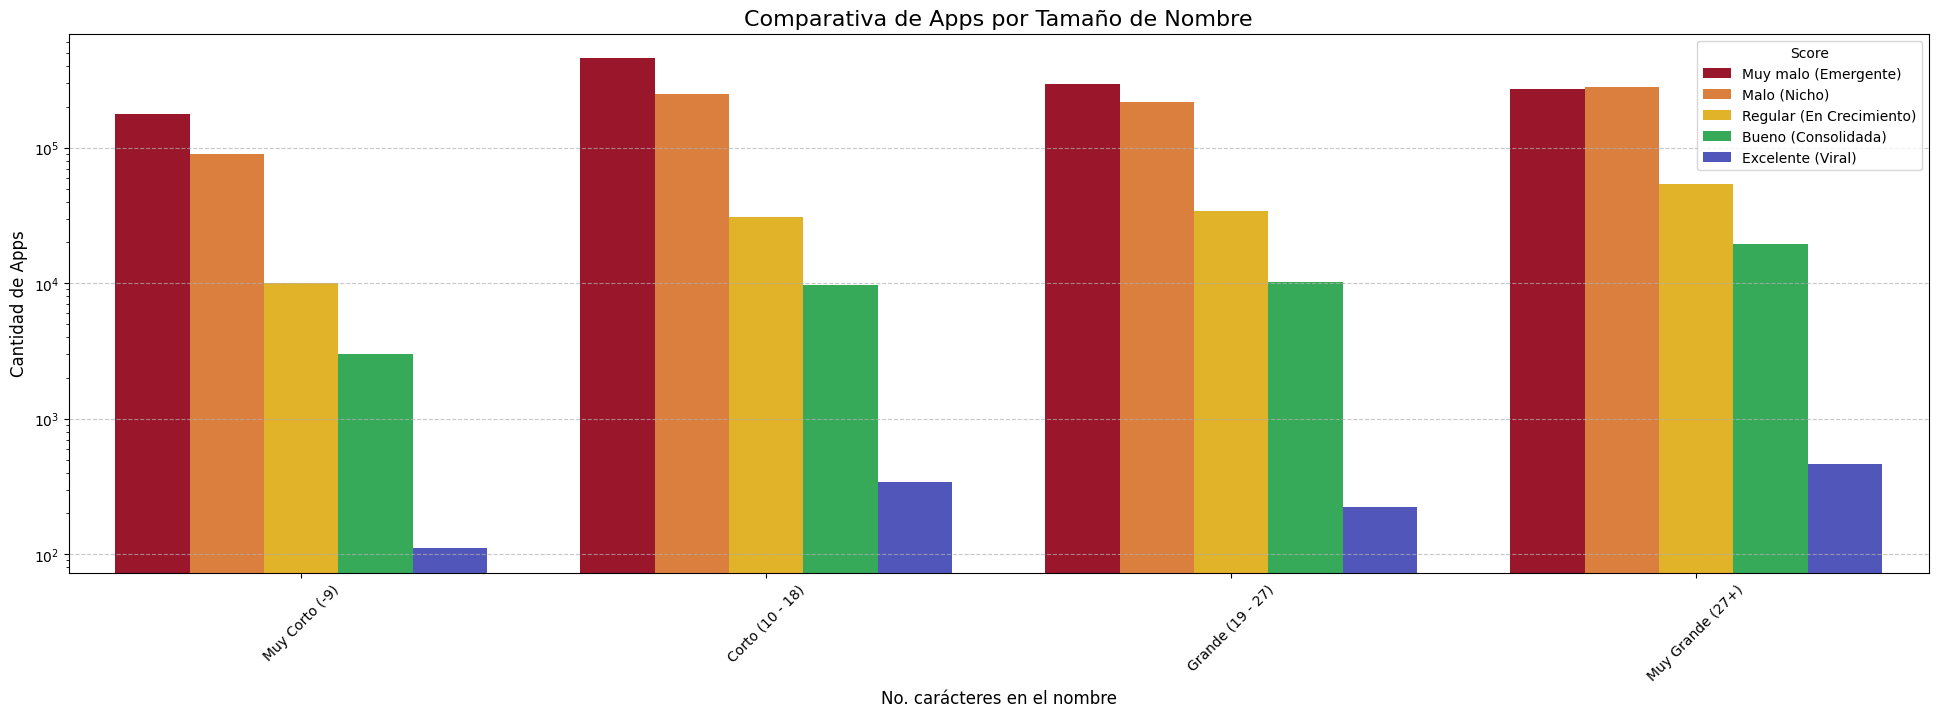

In [ ]:
plt.figure(figsize=(24, 7))

orden = ['Muy Corto (-9)', 'Corto (10 - 18)', 'Grande (19 - 27)', 'Muy Grande (27+)']
ax = sns.countplot(data=df_ComparacionScore, x='Len Class', hue='Score', palette=paleta, order = orden)

ax.set_yscale("log")
plt.title('Comparativa de Apps por Tamaño de Nombre', fontsize=16)
plt.xlabel('No. carácteres en el nombre', fontsize=12)
plt.ylabel('Cantidad de Apps', fontsize=12)
#plt.legend(title='Calificación')
plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
del df_ComparacionScore
gc.collect()

14630

# Tamaño de Aplicaciones, Android, Categoria

In [ ]:
df_Info

,App Id,App Name,Category,Currency,Size,Android,Developer Id,Released_Month,Released_Year,L_Updated_Month,L_Updated_Year
0,com.ishakwe.gakondo,Gakondo,Adventure,USD,10M,7.1,Jean Confident Irénée NIYIZIBYOSE,2,2020,2,2020
1,com.webserveis.batteryinfo,Ampere Battery Info,Tools,USD,2.9M,5.0,Webserveis,5,2020,5,2021
2,com.doantiepvien.crm,Vibook,Productivity,USD,3.7M,4.0,Cabin Crew,8,2019,8,2019
3,cst.stJoseph.ug17ucs548,Smart City Trichy Public Service Vehicles 17UC...,Communication,USD,1.8M,4.0,Climate Smart Tech2,9,2018,10,2018
4,com.horodyski.grower,GROW.me,Tools,USD,6.2M,4.1,Rafal Milek-Horodyski,2,2020,11,2018
...,...,...,...,...,...,...,...,...,...,...,...
2211968,com.toefltimer,Lero TOEFL Recorder + Timer,Education,USD,10M,4.1,Julio Augusto Vera,5,2018,12,2018
2211969,com.threedream.oruonline,ORU Online,Education,USD,44M,4.1,"3Dream Studios, LLC",1,2018,2,2018
2211970,datastructure.appoworld.datastucture,Data Structure,Education,USD,29M,5.0,appoworld,8,2018,8,2018
2211971,ishan.devi.suktam,Devi Suktam,Music & Audio,USD,10M,5.0,Bhakti,8,2016,5,2021


In [ ]:
df_CompTam =     pd.merge(df_Cal[['App Id','Score']], df_Info[['App Id','Size']], on = 'App Id')
df_CompCat =     pd.merge(df_Cal[['App Id','Score']], df_Info[['App Id','Category']], on = 'App Id')
df_CompAndroid = pd.merge(df_Cal[['App Id','Score']], df_Info[['App Id','Android']], on = 'App Id')


In [ ]:
df_CompTam['Type'] = df_CompTam['Size'].str[-2:]
df_CompTam['Type'].unique()

array(['0M', '6M', '8M', '5M', '4M', '3M', '2M', '9M', '7M', '1M', 'ce',
       '6k', '5k', '9k', '2k', '4k', '7k', '8k', '1k', '3k', '0k', '1G',
       '5G', '0G'], dtype=object)

In [ ]:
df_CompTam[df_CompTam['Type'] == 'ce']

,App Id,Score,Size,Type
137,com.dirtybug.swipeepp,Muy malo,Varies with device,ce
158,com.enigma.immunity_guide,Muy malo,Varies with device,ce
647,com.sam.super_gym,Muy malo,Varies with device,ce
929,io.getknow.spigroup,Muy malo,Varies with device,ce
1605,com.jop.epidemic,Muy malo,Varies with device,ce
...,...,...,...,...
2211946,com.google.ar.lens,Excelente,Varies with device,ce
2211954,com.google.android.apps.plus,Excelente,Varies with device,ce
2211955,com.google.android.apps.nbu.files,Excelente,Varies with device,ce
2211962,com.king.candycrushsaga,Excelente,Varies with device,ce


In [ ]:
def sizebyte(app):
  app = app.replace(",","")
  if app[-1] == 'k':
    m = 0.001
  elif app[-1] == 'M':
    m = 1
  elif app[-1] == 'G':
    m = 1000
  else:
    return None
  return float(app[:-1])

In [ ]:
df_CompTam['Size (kb)'] = df_CompTam['Size'].apply(sizebyte)
df_CompTam = df_CompTam.dropna()
df_CompTam

,App Id,Score,Size,Size (kb)
0,com.wWordCross_8550728,Muy malo (Emergente),10M,10.0
1,com.kradioapp.voltagefrancegratuit,Muy malo (Emergente),7.6M,7.6
2,com.free074a81ba94cf6951221ca03606d56.user.ebo...,Muy malo (Emergente),6.8M,6.8
3,com.automotiveintelligence.ingridCustomerApp,Muy malo (Emergente),25M,25.0
4,com.advisorlynx.mobileadvisor.keen,Muy malo (Emergente),7.5M,7.5
...,...,...,...,...
2211968,flipboard.boxer.app,Excelente (Viral),18M,18.0
2211969,com.google.android.ims,Excelente (Viral),8.1M,8.1
2211970,com.sec.android.app.shealth,Excelente (Viral),85M,85.0
2211971,com.google.android.calculator,Excelente (Viral),2.6M,2.6


In [ ]:
def sizeClass(n):
  if n<=10:
    return 'Muy Corto (-50mb)'
  elif 10<n<=25:
    return 'Corto (51mb - 100mb)'
  elif 25<n<=50:
    return 'Grande (101mb - 800mb)'
  else:
    return 'Muy Grande (+800mb)'

In [ ]:
df_CompTam['Class_Size'] = df_CompTam['Size (kb)'].apply(sizeClass)

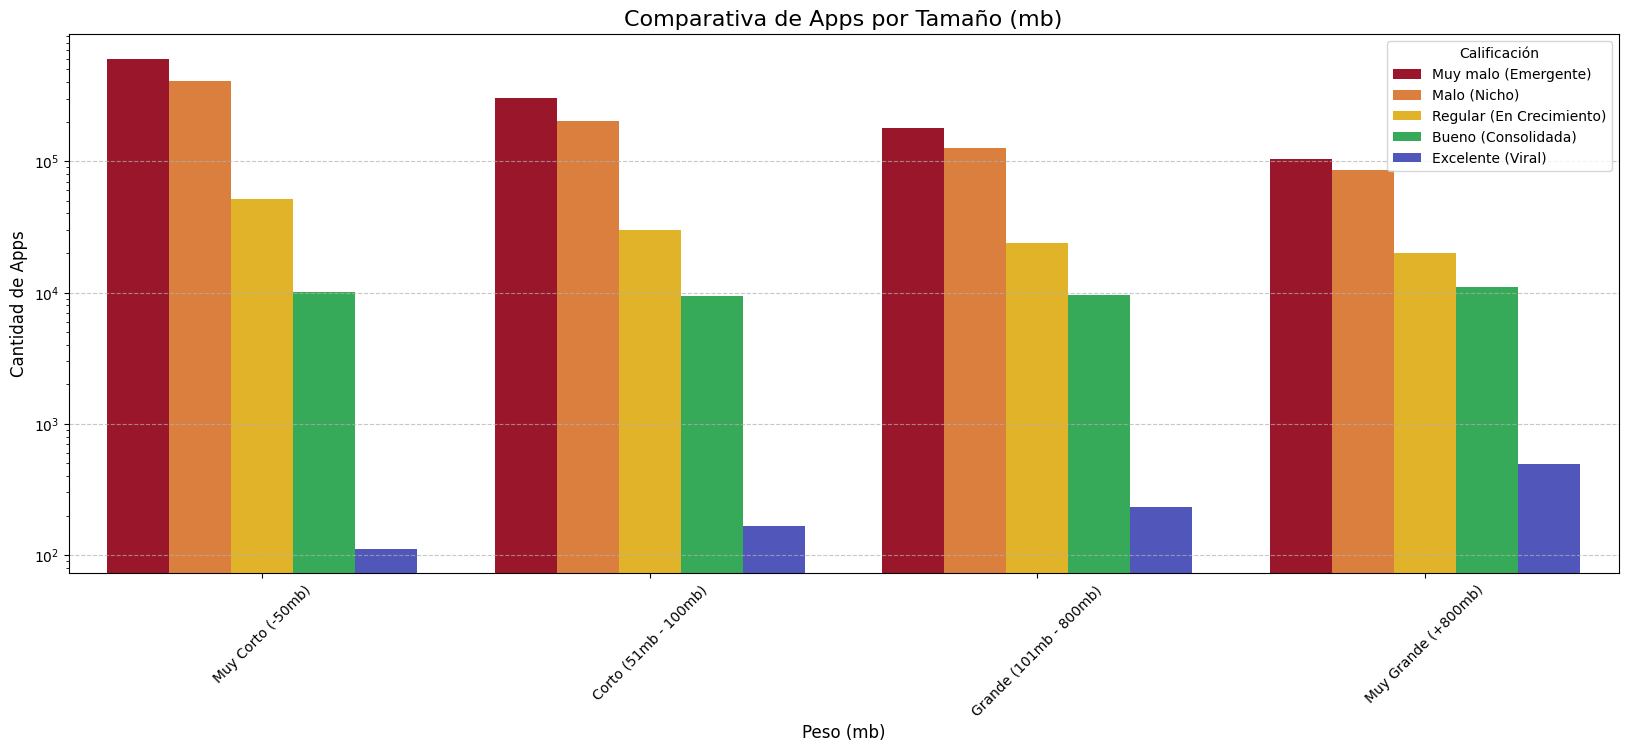

In [ ]:
plt.figure(figsize=(20, 7))

orden = ['Muy Corto (-50mb)', 'Corto (51mb - 100mb)', 'Grande (101mb - 800mb)', 'Muy Grande (+800mb)']
ax = sns.countplot(data = df_CompTam, x='Class_Size', hue='Score', palette=paleta, order = orden)

ax.set_yscale("log")
plt.title('Comparativa de Apps por Tamaño (mb)', fontsize=16)
plt.xlabel('Peso (mb)', fontsize=12)
plt.ylabel('Cantidad de Apps', fontsize=12)
plt.legend(title='Calificación')
plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
len(df_CompCat['Category'].unique())

48

In [ ]:
categorias1 = list(df_CompCat['Category'].unique())[:13]
categorias2 = list(df_CompCat['Category'].unique())[13:25]
categorias3 = list(df_CompCat['Category'].unique())[25:37]
categorias4 = list(df_CompCat['Category'].unique())[37:]

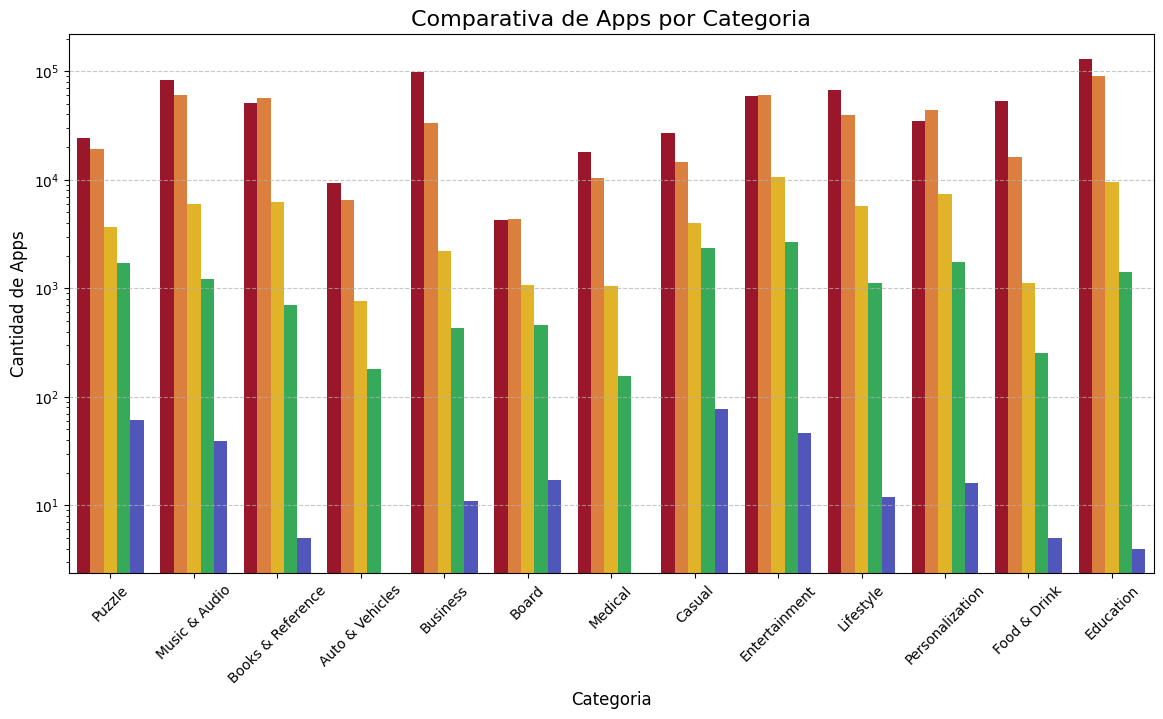

In [ ]:
plt.figure(figsize=(14, 7))

#orden = ['Muy Corto (-50mb)', 'Corto (51mb - 100mb)', 'Grande (101mb - 800mb)', 'Muy Grande (+800mb)']
ax = sns.countplot(data = df_CompCat[df_CompCat['Category'].isin(categorias1)],
                   x='Category', hue='Score', palette=paleta, legend = False)

ax.set_yscale("log")
plt.title('Comparativa de Apps por Categoria', fontsize=16)
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Cantidad de Apps', fontsize=12)
#plt.legend(title='Calificación')
plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

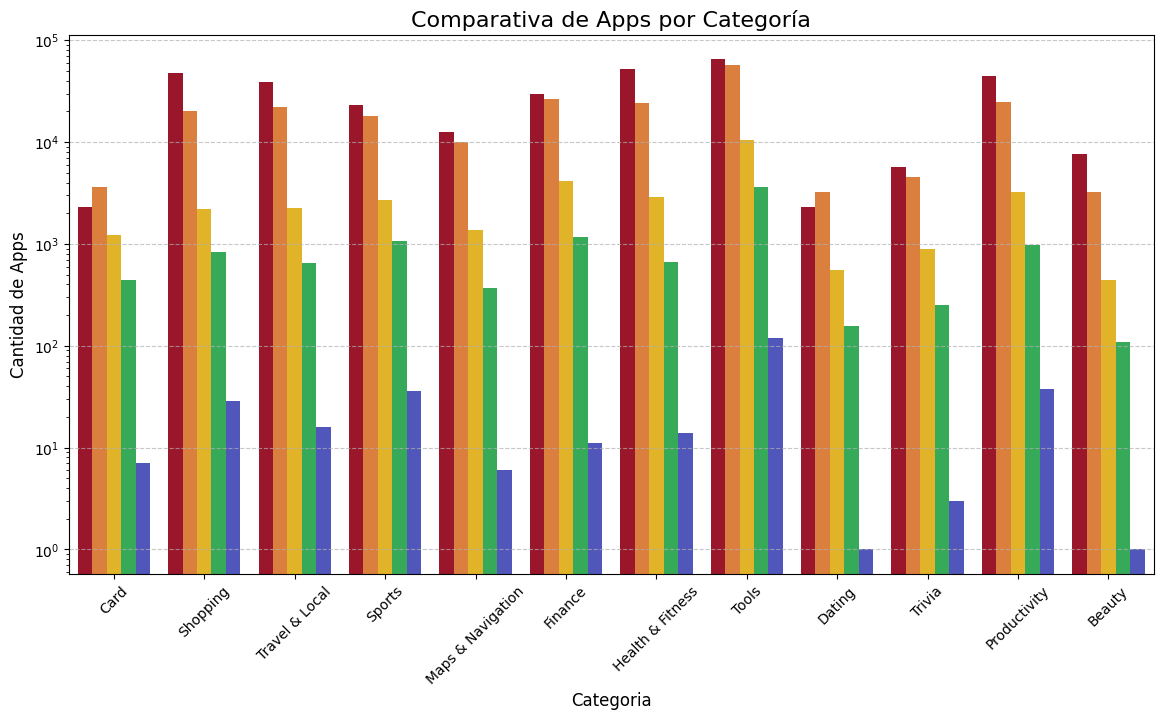

In [ ]:
plt.figure(figsize=(14, 7))

#orden = ['Muy Corto (-50mb)', 'Corto (51mb - 100mb)', 'Grande (101mb - 800mb)', 'Muy Grande (+800mb)']
ax = sns.countplot(data = df_CompCat[df_CompCat['Category'].isin(categorias2)],
                   x='Category', hue='Score', palette=paleta, legend = False)
ax.set_yscale("log")
plt.title('Comparativa de Apps por Categoría', fontsize=16)
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Cantidad de Apps', fontsize=12)
#plt.legend(title='Calificación')
plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

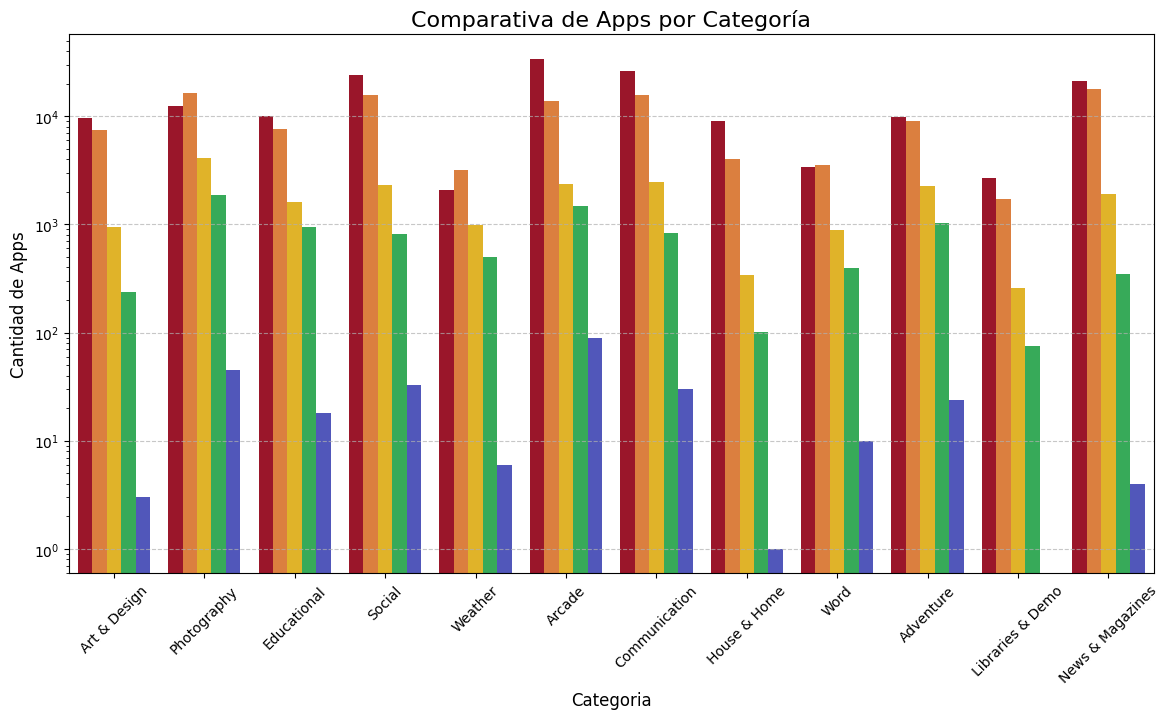

In [ ]:
plt.figure(figsize=(14, 7))

#orden = ['Muy Corto (-50mb)', 'Corto (51mb - 100mb)', 'Grande (101mb - 800mb)', 'Muy Grande (+800mb)']
ax = sns.countplot(data = df_CompCat[df_CompCat['Category'].isin(categorias3)],
                   x='Category', hue='Score', palette=paleta, legend =False)
ax.set_yscale("log")

plt.title('Comparativa de Apps por Categoría', fontsize=16)
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Cantidad de Apps', fontsize=12)
#plt.legend(title='Calificación')
plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

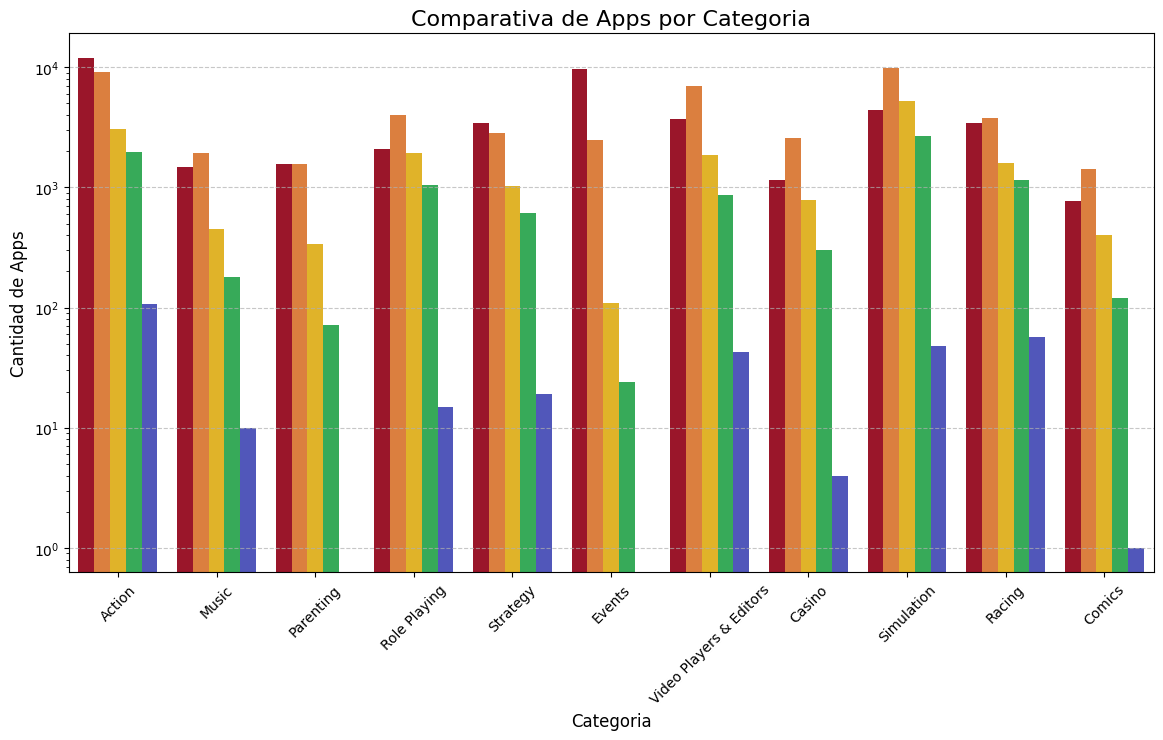

In [ ]:
plt.figure(figsize=(14, 7))

#orden = ['Muy Corto (-50mb)', 'Corto (51mb - 100mb)', 'Grande (101mb - 800mb)', 'Muy Grande (+800mb)']
ax = sns.countplot(data = df_CompCat[df_CompCat['Category'].isin(categorias4)],
                   x='Category', hue='Score', palette=paleta, legend= False)
ax.set_yscale("log")

plt.title('Comparativa de Apps por Categoria', fontsize=16)
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Cantidad de Apps', fontsize=12)
#plt.legend(title='Calificación')
plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
df_CompCat

,App Id,Score,Category
0,com.wWordCross_8550728,Muy malo,Puzzle
1,com.kradioapp.voltagefrancegratuit,Muy malo,Music & Audio
2,com.free074a81ba94cf6951221ca03606d56.user.ebo...,Muy malo,Books & Reference
3,com.automotiveintelligence.ingridCustomerApp,Muy malo,Auto & Vehicles
4,com.advisorlynx.mobileadvisor.keen,Muy malo,Business
...,...,...,...
2211968,flipboard.boxer.app,Excelente,News & Magazines
2211969,com.google.android.ims,Excelente,Communication
2211970,com.sec.android.app.shealth,Excelente,Health & Fitness
2211971,com.google.android.calculator,Excelente,Tools


In [ ]:
df_Cal['Score'].unique()

array(['Muy malo (Emergente)', 'Malo (Nicho)', 'Regular (En Crecimiento)',
       'Bueno (Consolidada)', 'Excelente (Viral)'], dtype=object)

In [ ]:
import math
df_counts = df_CompCat.pivot_table(index='Category',
                                   columns='Score',
                                   aggfunc='size',
                                   fill_value=0)

df_counts['Proporción'] = (df_counts['Excelente (Viral)'] + df_counts['Bueno (Consolidada)'] )/(df_counts['Malo (Nicho)'] + df_counts['Muy malo (Emergente)'])

In [ ]:
df_counts.sort_values(by = 'Proporción', ascending=False)

Score,Bueno (Consolidada),Excelente (Viral),Malo (Nicho),Muy malo (Emergente),Regular (En Crecimiento),Proporción
Category,,,,,,
Simulation,2673,48,9860,4404,5209,0.190760
Role Playing,1048,15,3993,2071,1920,0.175297
Racing,1148,57,3795,3435,1609,0.166667
Strategy,617,19,2830,3429,1031,0.101614
Action,1984,107,9176,11930,3059,0.099071
Weather,502,6,3177,2087,996,0.096505
Video Players & Editors,867,43,6991,3703,1865,0.085094
Casino,303,4,2590,1148,778,0.082129
Card,441,7,3634,2284,1214,0.075701


In [ ]:
df_ComparacionScore.head()

,App Id,Score,App Name,Len Name
0,com.wWordCross_8550728,Muy malo (Emergente),CrossWord,9
1,com.kradioapp.voltagefrancegratuit,Muy malo (Emergente),Voltage france gratuit,22
2,com.free074a81ba94cf6951221ca03606d56.user.ebo...,Muy malo (Emergente),"Book, Imperial Purple",21
3,com.automotiveintelligence.ingridCustomerApp,Muy malo (Emergente),Ingrid,6
4,com.advisorlynx.mobileadvisor.keen,Muy malo (Emergente),Keen Capital,12


In [ ]:
df_CompTam.head()

,App Id,Score,Size,Size (kb),Class_Size
0,com.wWordCross_8550728,Muy malo (Emergente),10M,10.0,Muy Corto (-50mb)
1,com.kradioapp.voltagefrancegratuit,Muy malo (Emergente),7.6M,7.6,Muy Corto (-50mb)
2,com.free074a81ba94cf6951221ca03606d56.user.ebo...,Muy malo (Emergente),6.8M,6.8,Muy Corto (-50mb)
3,com.automotiveintelligence.ingridCustomerApp,Muy malo (Emergente),25M,25.0,Corto (51mb - 100mb)
4,com.advisorlynx.mobileadvisor.keen,Muy malo (Emergente),7.5M,7.5,Muy Corto (-50mb)


In [ ]:
df_Corr = pd.merge(df_CompTam[['App Id','Score', 'Size (kb)']], df_ComparacionScore[['App Id','Len Name']], on = 'App Id')

In [ ]:
df_Corr['Score'].unique()

array(['Muy malo (Emergente)', 'Malo (Nicho)', 'Regular (En Crecimiento)',
       'Bueno (Consolidada)', 'Excelente (Viral)'], dtype=object)

In [ ]:
def numScore(s):
  if s=='Muy malo (Emergente)':
    return 1
  if s=='Malo (Nicho)':
    return 2
  if s=='Regular (En Crecimiento)':
    return 3
  if s=='Bueno (Consolidada)':
    return 4
  else:
    return 5

In [ ]:
df_Corr['Score'] = df_Corr['Score'].apply(numScore)

In [ ]:
corr = df_Corr.drop(columns = ['App Id']).corr()

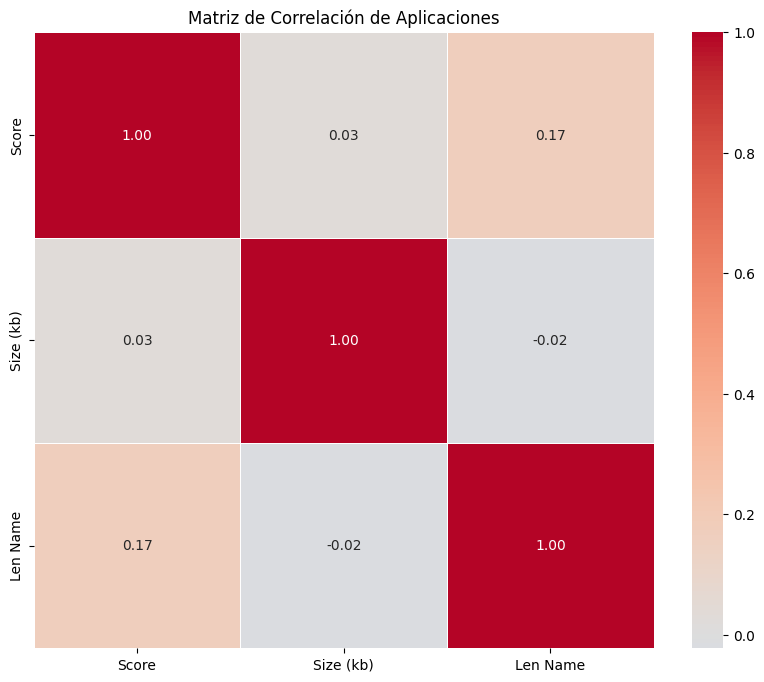

In [ ]:
# 2. Configurar el estilo y el lienzo
plt.figure(figsize=(10, 8))

# 3. Dibujar el heatmap
sns.heatmap(corr,
            annot=True,       # Muestra los números dentro de los cuadros
            fmt=".2f",        # Formato de 2 decimales
            cmap='coolwarm',  # Paleta de color (Rojo positivo, Azul negativo)
            center=0,         # El blanco será el 0
            linewidths=0.5)   # Espacio entre cuadros

plt.title('Matriz de Correlación de Aplicaciones')
plt.show()

In [ ]:
#df_CompTam =     pd.merge(df_Cal[['App Id','Score']], df_Info[['App Id','Size']], on = 'App Id')
#df_CompCat =     pd.merge(df_Cal[['App Id','Score']], df_Info[['App Id','Category']], on = 'App Id')
#df_CompAndroid = pd.merge(df_Cal[['App Id','Score']], df_Info[['App Id','Android']], on = 'App Id')

del df_CompTam
del df_CompCat
del df_CompAndroid
gc.collect()


32428

In [ ]:
"""
# Nuevos dataframes para facilitar lectura y organizar información
df_Cal = df_GP[['App Id','Rating','Rating Count','No. Installs','Score']].copy()    # Calificaciones
df_Info = df_GP[['App Id','App Name','Category','Currency','Size','Android','Developer Id',
                 'Released_Month', 'Released_Year','L_Updated_Month',
                 'L_Updated_Year']].copy()                                          # Información de la app
df_Mon = df_GP[['App Id','Free','Price','Ad Supported','In App Purchases']].copy()  # Monetización
"""

"\n# Nuevos dataframes para facilitar lectura y organizar información\ndf_Cal = df_GP[['App Id','Rating','Rating Count','No. Installs','Score']].copy()    # Calificaciones\ndf_Info = df_GP[['App Id','App Name','Category','Currency','Size','Android','Developer Id',\n                 'Released_Month', 'Released_Year','L_Updated_Month',\n                 'L_Updated_Year']].copy()                                          # Información de la app\ndf_Mon = df_GP[['App Id','Free','Price','Ad Supported','In App Purchases']].copy()  # Monetización\n"

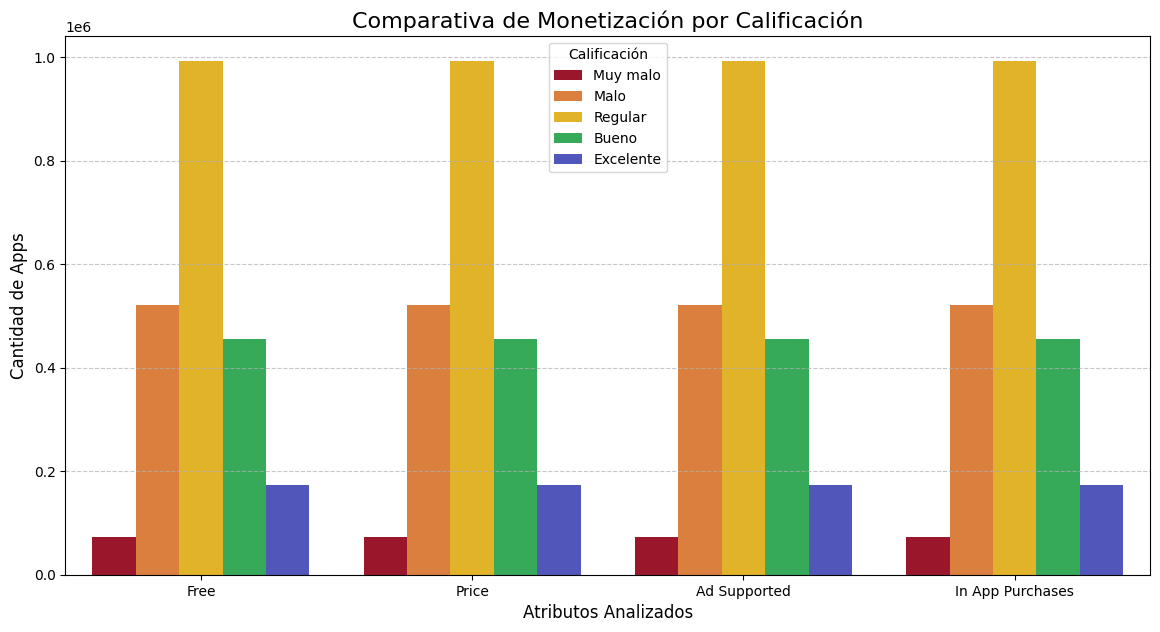

In [ ]:
df_Monetizacion = pd.merge(df_Cal[['App Id','Score']], df_Mon, on = 'App Id')

df_melted = df_Monetizacion.melt(id_vars=['Score'],
                            value_vars=['Free','Price','Ad Supported','In App Purchases'],
                            var_name='Variable',
                            value_name='Valor')

plt.figure(figsize=(14, 7))

ax = sns.countplot(data=df_melted,
                   x='Variable',
                   hue='Score',
                   palette=paleta)

plt.title('Comparativa de Monetización por Calificación', fontsize=16)
plt.xlabel('Atributos Analizados', fontsize=12)
plt.ylabel('Cantidad de Apps', fontsize=12)
plt.legend(title='Calificación')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
df_Mon

,App Id,Free,Price,Ad Supported,In App Purchases
0,com.ishakwe.gakondo,True,0.0,False,False
1,com.webserveis.batteryinfo,True,0.0,True,False
2,com.doantiepvien.crm,True,0.0,False,False
3,cst.stJoseph.ug17ucs548,True,0.0,True,False
4,com.horodyski.grower,True,0.0,False,False
...,...,...,...,...,...
2211968,com.toefltimer,True,0.0,True,False
2211969,com.threedream.oruonline,True,0.0,False,False
2211970,datastructure.appoworld.datastucture,True,0.0,False,False
2211971,ishan.devi.suktam,True,0.0,True,False


In [ ]:
corr = df_Cal.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(corr,
            annot=True,       # Muestra los números dentro de los cuadros
     #       fmt=".2f",        # Formato de 2 decimales
            cmap='coolwarm_r',  # Paleta de color (Rojo positivo, Azul negativo)
            center=0,         # El blanco será el 0
            linewidths=0.5)   # Espacio entre cuadros

plt.title('Matriz de Correlación de Calificaciones en Aplicaciones')
plt.show()

ValueError: could not convert string to float: 'com.wWordCross_8550728'

In [ ]:
plt.figure(figsize=(14, 7))

#orden = ['Muy Corto (-50mb)', 'Corto (51mb - 100mb)', 'Grande (101mb - 800mb)', 'Muy Grande (+800mb)']
ax = sns.countplot(data = df_Monetizacion,
                   x='Free', hue='Score', palette=paleta)

plt.title('Comparativa de Apps por Gratis/De pago', fontsize=16)
plt.xlabel('', fontsize=12)
plt.ylabel('Cantidad de Apps', fontsize=12)
plt.legend(title='Calificación')
plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
ColumnasO = ['App Name', 'App Id', 'Category', 'Rating', 'Rating Count', 'Installs',
       'Minimum Installs', 'Maximum Installs', 'Free', 'Price', 'Currency',
       'Size', 'Minimum Android', 'Developer Id', 'Developer Website',
       'Developer Email', 'Released', 'Last Updated', 'Content Rating',
       'Privacy Policy', 'Ad Supported', 'In App Purchases', 'Editors Choice',
       'Scraped Time']
print('Columnas:\n\n')
for c in ColumnasO:
  print(c)

In [ ]:
print('Total de entradas:\n2,312,944')

In [ ]:
sum = df_Cal['Score'].value_counts().sum()
for i in df_Cal['Score'].value_counts():
  print(i/sum)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df_Cal.to_csv('/content/drive/MyDrive/GooglePlay_Cal.csv', index=False)
df_Info.to_csv('/content/drive/MyDrive/GooglePlay_Info.csv', index=False)
df_Mon.to_csv('/content/drive/MyDrive/GooglePlay_Mon.csv', index=False)